# 4. Model Evaluation & Save Best Pose Model

Deep-dive evaluation of the **winning pose model** from notebook 3.  
Visualise keypoint overlays, analyse temporal stability, then export to `models/best_model/`.

| Saved file | Purpose |
|---|---|
| `models/best_model/best_model.pt` | YOLO Pose weights |
| `models/best_model/best_model_info.json` | metrics + config |
| `models/best_model/feature_stats.json` | per-feature mean/std for normalisation |

**Depends on:** `2.data_preparation.ipynb` and `3.model_comparison.ipynb` completed.

In [1]:
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['ultralytics', 'opencv-python', 'pandas', 'matplotlib', 'tqdm', 'scikit-learn']:
    install(pkg)
print('Dependencies ready.')

Dependencies ready.


In [2]:
import cv2, json, shutil, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT           = Path('..').resolve()
KD_DIR         = ROOT / 'keypoint_detector'
KPS_DIR        = KD_DIR / 'data' / 'keypoints'
BEST_MODEL_DIR = KD_DIR / 'models' / 'best_model'
BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)

PD_DIR     = ROOT / 'person_detector'
FRAMES_DIR = PD_DIR / 'data' / 'frames'

FEATURE_COLS = [
    'left_elbow_angle', 'right_elbow_angle', 'elbow_symmetry',
    'left_hip_angle',   'right_hip_angle',
    'body_straightness', 'shoulder_height', 'hip_height'
]

COCO_KPS = [
    'nose','l_eye','r_eye','l_ear','r_ear',
    'l_shoulder','r_shoulder','l_elbow','r_elbow',
    'l_wrist','r_wrist','l_hip','r_hip',
    'l_knee','r_knee','l_ankle','r_ankle'
]

# ── Load best model choice ────────────────────────────────────────────────────
choice_path = KD_DIR / 'best_model_choice.json'
if not choice_path.exists():
    raise FileNotFoundError('best_model_choice.json not found — run notebook 3 first.')

choice   = json.loads(choice_path.read_text())
BEST_PT  = choice['model_id']         # e.g. 'yolo11m-pose.pt'
MODEL_ID = BEST_PT.replace('.pt','')  # e.g. 'yolo11m-pose'

print(f'Best model    : {BEST_PT}')
print(f'Score         : {choice["score"]}')
print(f'Feat complete : {choice["feat_completeness"]}')
print(f'Elbow quality : {choice["elbow_quality"]}')
print(f'Latency       : {choice["avg_ms"]} ms')

Best model    : yolov8n-pose.pt
Score         : 1.0
Feat complete : 0.975
Elbow quality : 0.993
Latency       : 44.3 ms


In [3]:
# Load the model
model = YOLO(BEST_PT)
print(f'Model loaded: {BEST_PT}')

Model loaded: yolov8n-pose.pt


## 4.1 Shared Helpers

In [4]:
SKELETON = [
    (5,7),(7,9),          # left arm
    (6,8),(8,10),         # right arm
    (5,6),(5,11),(6,12),  # shoulders + torso top
    (11,12),              # hips
    (11,13),(13,15),      # left leg
    (12,14),(14,16),      # right leg
]

KP_COLORS = {
    'pushup': '#FF9800',   # joints used in push-up features
    'other' : '#9E9E9E',
}

PUSHUP_IDX = {5,6,7,8,9,10,11,12,13,14,15,16}


def draw_pose(img_bgr, kps, conf_thresh=0.3):
    """
    Draw keypoints + skeleton onto image (in-place copy).
    kps: (17,3) numpy array [x, y, conf]
    """
    img = img_bgr.copy()
    h, w = img.shape[:2]

    # Draw skeleton
    for a, b in SKELETON:
        if kps[a,2] > conf_thresh and kps[b,2] > conf_thresh:
            p1 = (int(kps[a,0]), int(kps[a,1]))
            p2 = (int(kps[b,0]), int(kps[b,1]))
            cv2.line(img, p1, p2, (200,200,200), 2)

    # Draw keypoints
    for i in range(17):
        if kps[i,2] > conf_thresh:
            x, y = int(kps[i,0]), int(kps[i,1])
            color = (0, 165, 255) if i in PUSHUP_IDX else (150, 150, 150)
            cv2.circle(img, (x,y), 5, color, -1)
            cv2.circle(img, (x,y), 5, (255,255,255), 1)

    return img


def angle_3pts(a, b, c):
    ba = np.array(a) - np.array(b)
    bc = np.array(c) - np.array(b)
    cos_a = np.dot(ba, bc) / (np.linalg.norm(ba)*np.linalg.norm(bc)+1e-9)
    return float(np.degrees(np.arccos(np.clip(cos_a,-1,1))))


def load_kps_df(model_id: str) -> pd.DataFrame:
    model_dir = KPS_DIR / model_id
    rows = []
    for jf in sorted(model_dir.glob('*.json')):
        records = json.loads(jf.read_text())
        for r in records:
            row = {'video': jf.stem, 'frame': r['frame'], 'label': r['label'],
                   'detected': r['keypoints'] is not None}
            if r['features']:
                row.update(r['features'])
            rows.append(row)
    df = pd.DataFrame(rows)
    for col in FEATURE_COLS:
        if col not in df.columns: df[col] = np.nan
    return df


print('Helpers ready.')

Helpers ready.


## 4.2 Keypoint Visualisation Grid

Overlay the full COCO skeleton on sample frames from both classes.

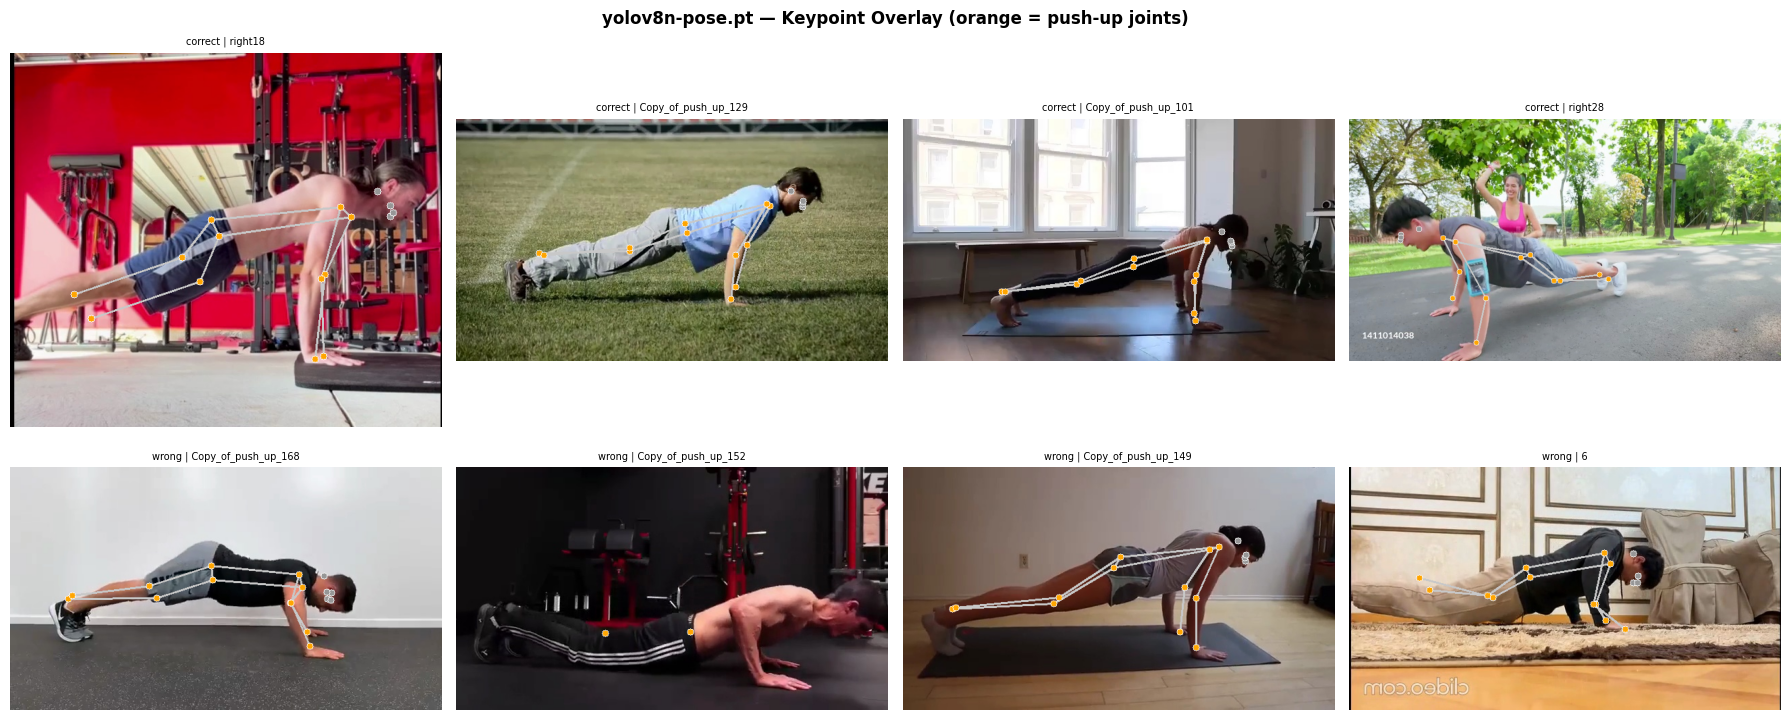

In [5]:
import random; random.seed(42)

correct_frames = sorted((FRAMES_DIR/'correct').rglob('*.jpg'))
wrong_frames   = sorted((FRAMES_DIR/'wrong').rglob('*.jpg'))

CONF = 0.3

# Pick 4 correct + 4 wrong
picks = [(p,'correct') for p in random.sample(correct_frames, min(4,len(correct_frames)))] + \
        [(p,'wrong')   for p in random.sample(wrong_frames,   min(4,len(wrong_frames)))]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, (path, label) in zip(axes, picks):
    img_bgr = cv2.imread(str(path))
    if img_bgr is None: ax.axis('off'); continue

    res = model(img_bgr, conf=CONF, verbose=False)[0]

    if res.keypoints is not None and len(res.keypoints) > 0:
        boxes = res.boxes.xyxy.cpu().numpy()
        areas = (boxes[:,2]-boxes[:,0]) * (boxes[:,3]-boxes[:,1])
        best  = int(np.argmax(areas))
        kps   = res.keypoints.data.cpu().numpy()[best]
        vis   = draw_pose(img_bgr, kps, CONF)
    else:
        vis = img_bgr

    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    border = '#4CAF50' if label=='correct' else '#F44336'
    for sp in ax.spines.values(): sp.set_edgecolor(border); sp.set_linewidth(3)
    ax.set_title(f'{label} | {path.parent.name}', fontsize=7)
    ax.axis('off')

fig.suptitle(f'{BEST_PT} — Keypoint Overlay (orange = push-up joints)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.3 Angle Annotations on Frames

Draw computed angles directly on images to verify correctness.

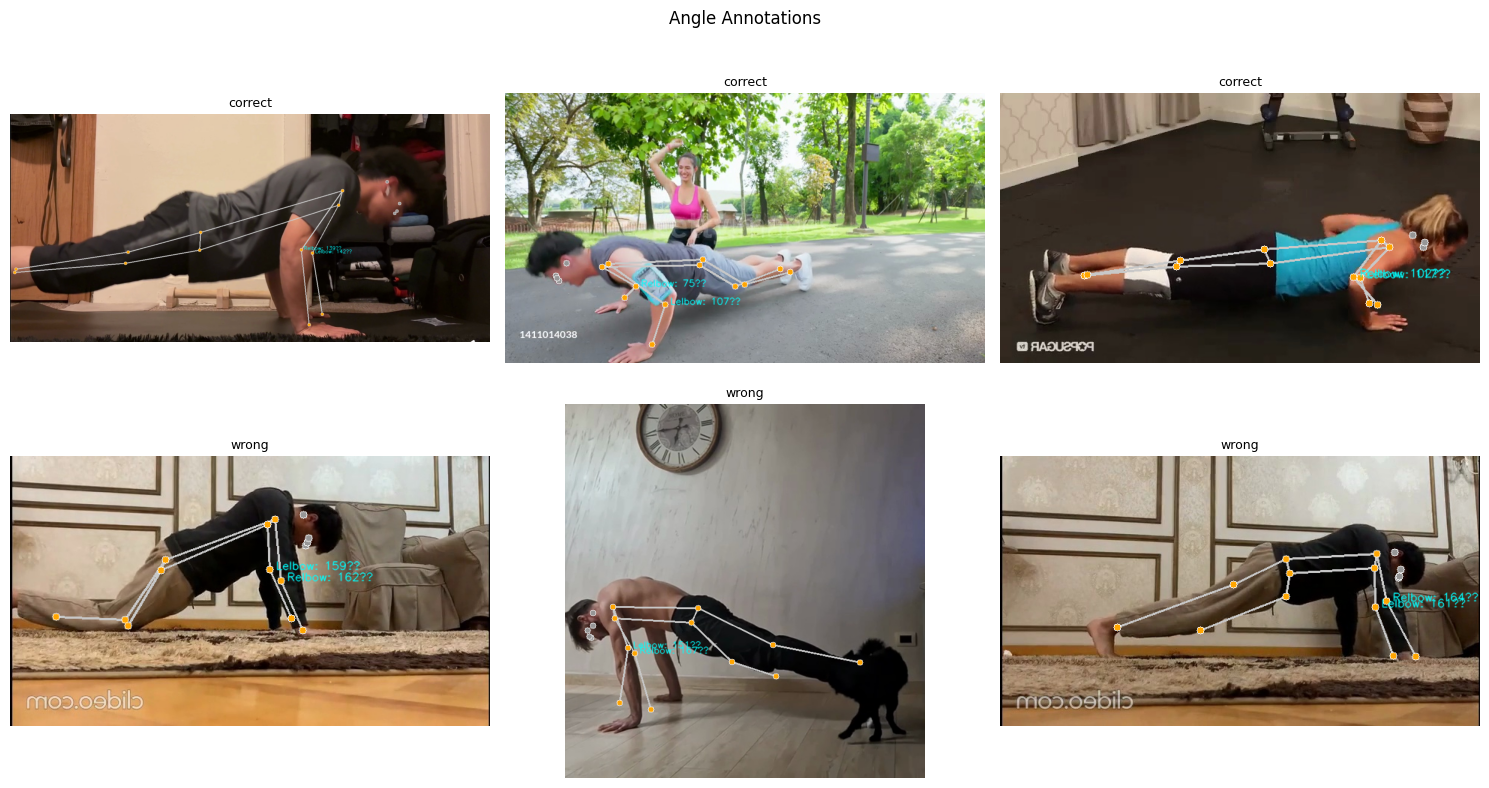

In [6]:
def annotate_angles(img_bgr, kps, conf_thresh=0.3):
    """Overlay elbow angles and body-alignment info onto frame."""
    img = draw_pose(img_bgr, kps, conf_thresh)

    def pt(i):
        return kps[i,:2].astype(int) if kps[i,2] > conf_thresh else None

    def put_angle(angle_val, joint_pt, label):
        if joint_pt is None or angle_val is None: return
        x, y = joint_pt
        text = f'{label}: {angle_val:.0f}°'
        cv2.putText(img, text, (x+8, y), cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (255,255,0), 1, cv2.LINE_AA)

    # Elbow angles
    for sh_i, el_i, wr_i, label in [(5,7,9,'L'),(6,8,10,'R')]:
        sh, el, wr = pt(sh_i), pt(el_i), pt(wr_i)
        if sh is not None and el is not None and wr is not None:
            ang = angle_3pts(sh, el, wr)
            put_angle(ang, el, f'{label}elbow')

    return img


picks2 = [(p,'correct') for p in random.sample(correct_frames, min(3,len(correct_frames)))] + \
         [(p,'wrong')   for p in random.sample(wrong_frames,   min(3,len(wrong_frames)))]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (path, label) in zip(axes, picks2):
    img_bgr = cv2.imread(str(path))
    if img_bgr is None: ax.axis('off'); continue

    res = model(img_bgr, conf=CONF, verbose=False)[0]
    if res.keypoints is not None and len(res.keypoints) > 0:
        boxes = res.boxes.xyxy.cpu().numpy()
        best  = int(np.argmax((boxes[:,2]-boxes[:,0])*(boxes[:,3]-boxes[:,1])))
        kps   = res.keypoints.data.cpu().numpy()[best]
        vis   = annotate_angles(img_bgr, kps, CONF)
    else:
        vis = img_bgr

    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    border = '#4CAF50' if label=='correct' else '#F44336'
    for sp in ax.spines.values(): sp.set_edgecolor(border); sp.set_linewidth(3)
    ax.set_title(f'{label}', fontsize=9); ax.axis('off')

fig.suptitle('Angle Annotations', fontsize=12)
plt.tight_layout(); plt.show()

## 4.4 Temporal Stability — Angle Curves

Plot elbow angle time series for several videos to confirm smooth, plausible oscillation.

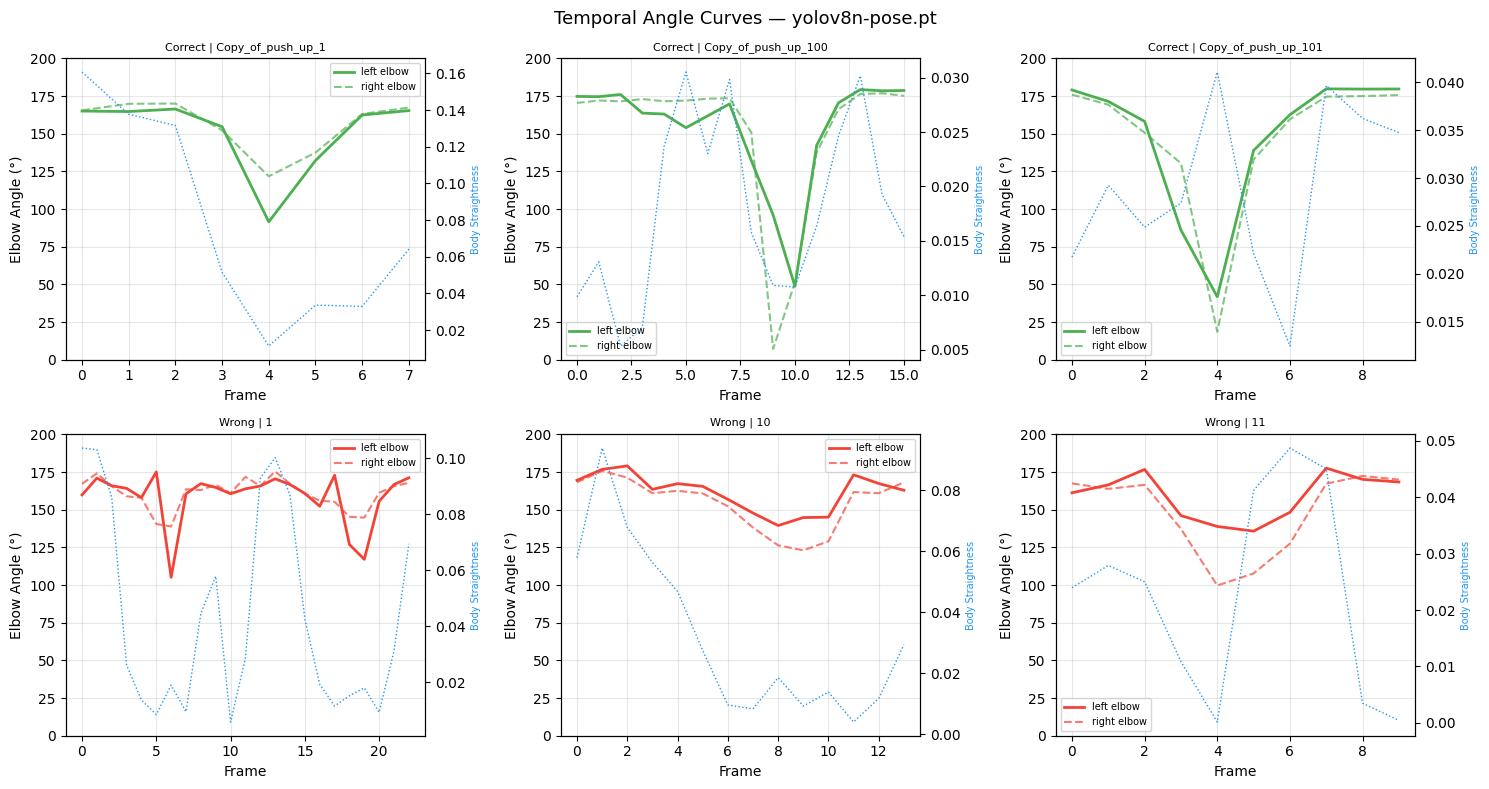

In [7]:
kps_model_dir = KPS_DIR / MODEL_ID
json_files = sorted(kps_model_dir.glob('*.json')) if kps_model_dir.exists() else []

correct_jsons = [jf for jf in json_files if
                 len(recs:=json.loads(jf.read_text())) > 0 and recs[0]['label']=='correct']
wrong_jsons   = [jf for jf in json_files if
                 len(recs:=json.loads(jf.read_text())) > 0 and recs[0]['label']=='wrong']

n_show = 3
fig, axes = plt.subplots(2, n_show, figsize=(5*n_show, 8))

for row_idx, (files, row_label, row_color) in enumerate([
    (correct_jsons[:n_show], 'Correct', '#4CAF50'),
    (wrong_jsons[:n_show],   'Wrong',   '#F44336'),
]):
    for col_idx, jf in enumerate(files):
        ax = axes[row_idx][col_idx]
        records = json.loads(jf.read_text())
        feats   = [r for r in records if r['features'] is not None]

        t     = list(range(len(feats)))
        l_ang = [r['features'].get('left_elbow_angle')  for r in feats]
        r_ang = [r['features'].get('right_elbow_angle') for r in feats]
        body  = [r['features'].get('body_straightness') for r in feats]

        ax.plot(t, l_ang, color=row_color, lw=2,   label='left elbow')
        ax.plot(t, r_ang, color=row_color, lw=1.5, linestyle='--', label='right elbow', alpha=0.7)
        ax2 = ax.twinx()
        ax2.plot(t, body, color='#2196F3', lw=1, linestyle=':', label='body straight')
        ax2.set_ylabel('Body Straightness', fontsize=7, color='#2196F3')

        ax.set_title(f'{row_label} | {jf.stem}', fontsize=8)
        ax.set_xlabel('Frame'); ax.set_ylabel('Elbow Angle (°)')
        ax.set_ylim(0, 200); ax.legend(fontsize=7); ax.grid(alpha=0.3)

    # Fill unused subplots
    for col_idx in range(len(files), n_show):
        axes[row_idx][col_idx].axis('off')

fig.suptitle(f'Temporal Angle Curves — {BEST_PT}', fontsize=13)
plt.tight_layout()
plt.show()

## 4.5 Keypoint Confidence Per Joint

Keypoint confidence: 100%|██████████| 100/100 [00:05<00:00, 19.65it/s]


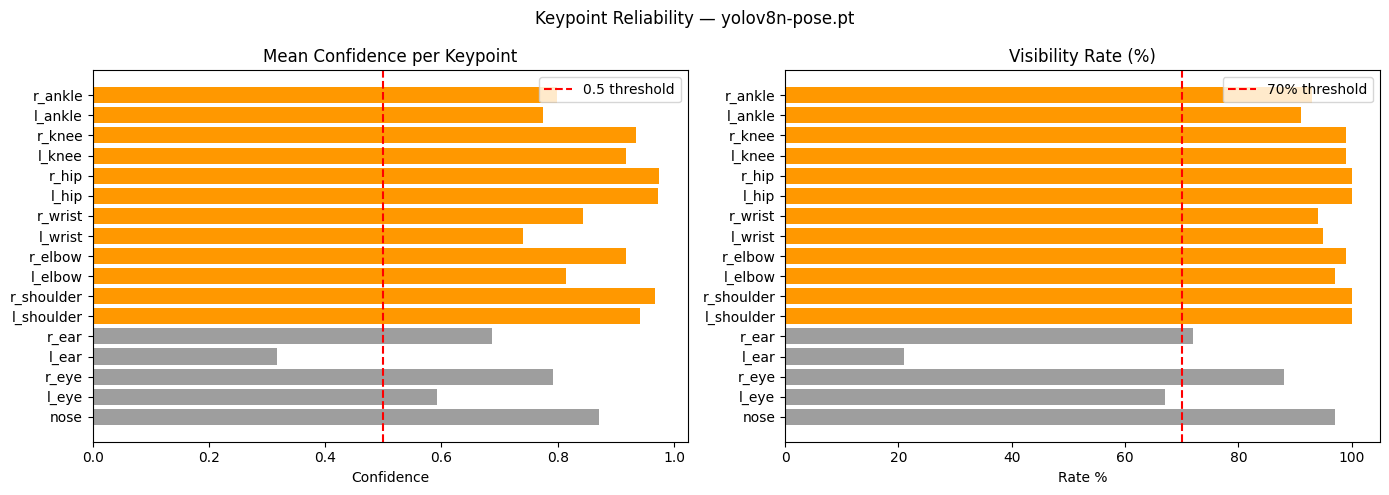


Low confidence joints (mean < 0.5):
  l_ear: 0.316


In [8]:
import random; random.seed(0)
probe_frames = random.sample(correct_frames + wrong_frames, min(100, len(correct_frames+wrong_frames)))

all_confs = []
for fp in tqdm(probe_frames, desc='Keypoint confidence'):
    img = cv2.imread(str(fp))
    if img is None: continue
    res = model(img, conf=0.3, verbose=False)[0]
    if res.keypoints is None or len(res.keypoints) == 0: continue
    boxes = res.boxes.xyxy.cpu().numpy()
    best  = int(np.argmax((boxes[:,2]-boxes[:,0])*(boxes[:,3]-boxes[:,1])))
    all_confs.append(res.keypoints.data.cpu().numpy()[best, :, 2])

if all_confs:
    arr = np.array(all_confs)   # (N, 17)
    mean_c = arr.mean(axis=0)
    vis_r  = (arr > 0.5).mean(axis=0)
    PUSHUP_IDX = {5,6,7,8,9,10,11,12,13,14,15,16}
    colors = ['#FF9800' if i in PUSHUP_IDX else '#9E9E9E' for i in range(17)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.barh(COCO_KPS, mean_c, color=colors)
    ax1.axvline(0.5, color='red', linestyle='--', label='0.5 threshold')
    ax1.set_title('Mean Confidence per Keypoint'); ax1.set_xlabel('Confidence'); ax1.legend()

    ax2.barh(COCO_KPS, vis_r*100, color=colors)
    ax2.axvline(70, color='red', linestyle='--', label='70% threshold')
    ax2.set_title('Visibility Rate (%)'); ax2.set_xlabel('Rate %'); ax2.legend()

    fig.suptitle(f'Keypoint Reliability — {BEST_PT}', fontsize=12)
    plt.tight_layout(); plt.show()

    # Report low-confidence joints
    print('\nLow confidence joints (mean < 0.5):')
    for name, c in zip(COCO_KPS, mean_c):
        if c < 0.5: print(f'  {name}: {c:.3f}')

## 4.6 Feature Statistics for LSTM Normalisation

Compute mean/std per feature across the full dataset.  
These are saved as `feature_stats.json` and used during LSTM training to standardize inputs.

In [9]:
df_all = load_kps_df(MODEL_ID)
detected = df_all[df_all.detected]

feature_stats = {}
for col in FEATURE_COLS:
    vals = detected[col].dropna()
    feature_stats[col] = {
        'mean'  : round(float(vals.mean()), 4)  if len(vals) > 0 else 0.0,
        'std'   : round(float(vals.std()), 4)   if len(vals) > 1 else 1.0,
        'min'   : round(float(vals.min()), 4)   if len(vals) > 0 else 0.0,
        'max'   : round(float(vals.max()), 4)   if len(vals) > 0 else 1.0,
        'nan_pct': round(float(detected[col].isna().mean()*100), 2),
    }

feat_stats_path = BEST_MODEL_DIR / 'feature_stats.json'
feat_stats_path.write_text(json.dumps(feature_stats, indent=2))
print(f'Saved feature_stats.json')

df_stats = pd.DataFrame(feature_stats).T
print('\nFeature statistics:')
print(df_stats.to_string())

Saved feature_stats.json

Feature statistics:
                       mean      std      min       max  nan_pct
left_elbow_angle   147.1410  30.2586   0.9649  179.9720     0.11
right_elbow_angle  147.7227  28.4252   4.1435  180.0000     0.61
elbow_symmetry      11.8326  14.7270   0.0056  127.6109     0.66
left_hip_angle     150.0527  24.5435  18.2473  179.9720     0.22
right_hip_angle    149.9410  21.4214  21.3547  179.9720     0.17
body_straightness    0.0427   0.0380   0.0001    0.2410     1.93
shoulder_height      0.4745   0.1456   0.0542    0.8373     0.11
hip_height           0.5251   0.1215   0.2055    0.8463     0.11


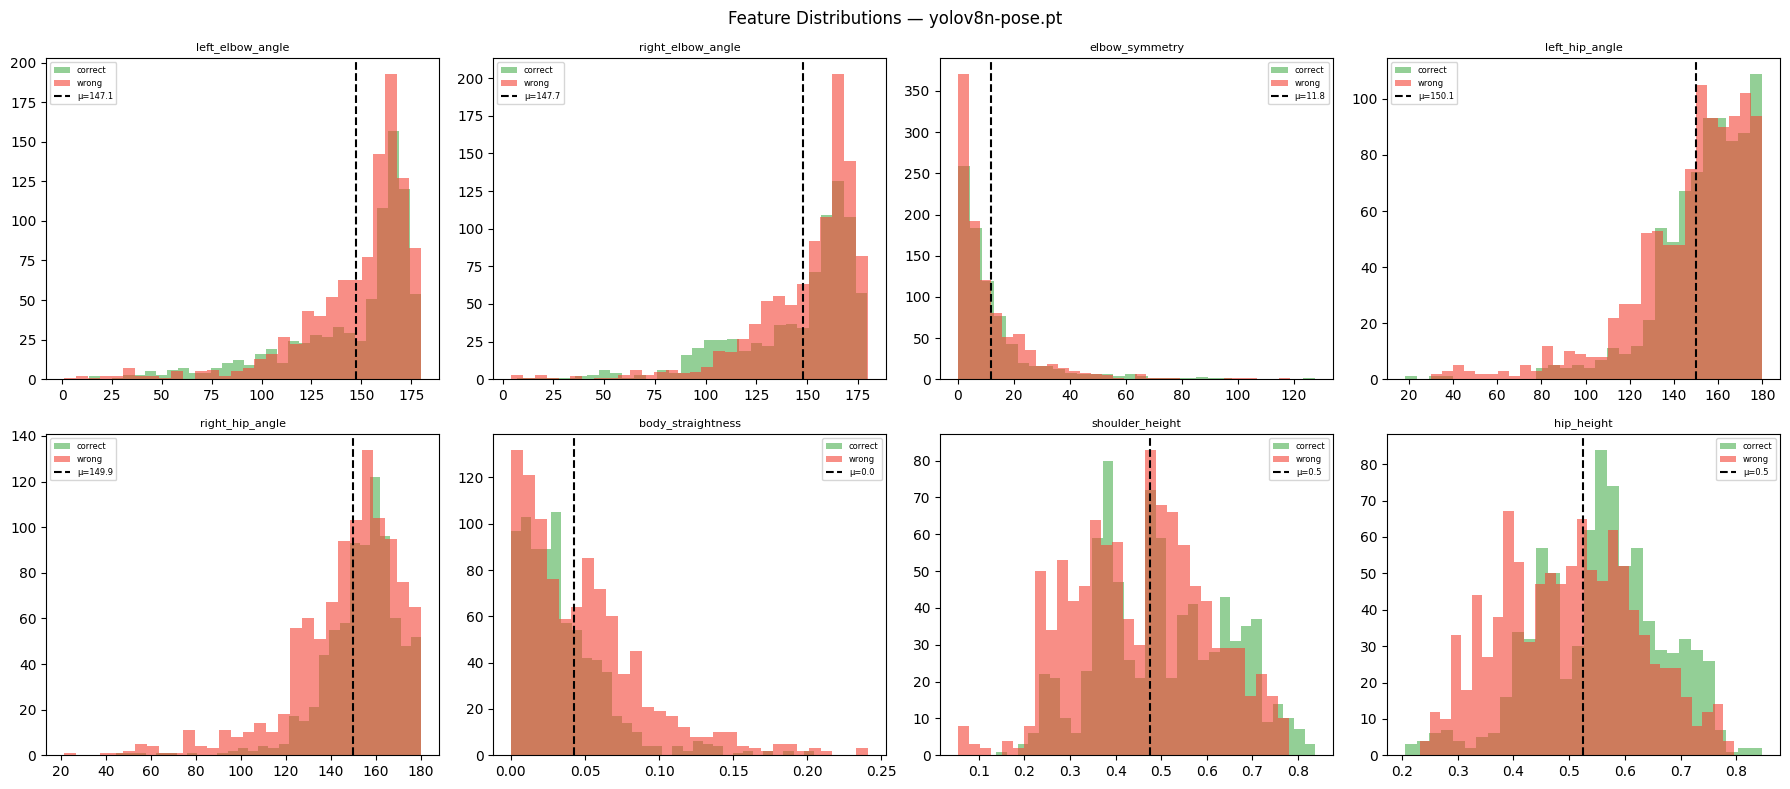

In [10]:
# Visualise feature stats
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), FEATURE_COLS):
    for label, color in [('correct','#4CAF50'),('wrong','#F44336')]:
        vals = df_all[(df_all.label==label) & df_all.detected][col].dropna()
        ax.hist(vals, bins=30, alpha=0.6, color=color, label=label)
    mean = feature_stats[col]['mean']
    ax.axvline(mean, color='black', linestyle='--', label=f'μ={mean:.1f}')
    ax.set_title(col, fontsize=8)
    ax.legend(fontsize=6)

fig.suptitle(f'Feature Distributions — {BEST_PT}', fontsize=12)
plt.tight_layout()
plt.show()

## 4.7 Save Best Model

In [11]:
# ── Copy .pt weights to best_model dir ──────────────────────────────────────
# YOLO downloads weights to ~/.config/Ultralytics/ or cwd — find it
import glob, os

def find_weights(pt_name):
    """Search common locations for the downloaded weights file."""
    search_dirs = [
        Path.cwd(),
        Path.home() / '.config' / 'Ultralytics',
        Path.home() / 'ultralytics',
    ]
    for d in search_dirs:
        found = list(d.rglob(pt_name))
        if found: return found[0]
    # Last resort: let ultralytics return the path
    return None

src_pt = find_weights(BEST_PT)
dst_pt = BEST_MODEL_DIR / 'best_model.pt'

if src_pt and src_pt.exists():
    shutil.copy2(src_pt, dst_pt)
    print(f'Copied {src_pt} → {dst_pt}')
else:
    # The YOLO object already knows where its weights are
    model.save(str(dst_pt))
    print(f'Saved model via YOLO.save() → {dst_pt}')

Copied /Users/haleytran/Downloads/pushup_judge/keypoint_detector/yolov8n-pose.pt → /Users/haleytran/Downloads/pushup_judge/keypoint_detector/models/best_model/best_model.pt


In [12]:
# ── Save model info JSON ──────────────────────────────────────────────────────
model_info = {
    'model_id'          : BEST_PT,
    'task'              : 'pose',
    'n_keypoints'       : 17,
    'keypoint_names'    : COCO_KPS,
    'feature_cols'      : FEATURE_COLS,
    'score'             : choice['score'],
    'feat_completeness' : choice['feat_completeness'],
    'elbow_quality'     : choice['elbow_quality'],
    'avg_ms'            : choice['avg_ms'],
    'conf_thresh'       : 0.3,
    'det_conf'          : 0.5,
}

info_path = BEST_MODEL_DIR / 'best_model_info.json'
info_path.write_text(json.dumps(model_info, indent=2))
print(f'\nSaved best_model_info.json')

print('\n=== Saved files ===')
for f in sorted(BEST_MODEL_DIR.iterdir()):
    print(f'  {f.name}  ({f.stat().st_size/1024:.1f} KB)')


Saved best_model_info.json

=== Saved files ===
  best_model.pt  (6672.5 KB)
  best_model_info.json  (0.7 KB)
  feature_stats.json  (1.0 KB)


## 4.8 Quick Smoke Test — Best Model

In [13]:
# Load from saved path and run one frame — confirm round-trip works
saved_model = YOLO(str(dst_pt))

if correct_frames:
    test_img = cv2.imread(str(correct_frames[0]))
    result   = saved_model(test_img, conf=0.3, verbose=False)[0]
    print(f'Test frame  : {correct_frames[0].name}')
    print(f'People found: {len(result.keypoints) if result.keypoints is not None else 0}')
    if result.keypoints is not None and len(result.keypoints) > 0:
        boxes = result.boxes.xyxy.cpu().numpy()
        best  = int(np.argmax((boxes[:,2]-boxes[:,0])*(boxes[:,3]-boxes[:,1])))
        kps   = result.keypoints.data.cpu().numpy()[best]
        vis_kps = (kps[:,2] > 0.3).sum()
        print(f'Visible KPs : {vis_kps}/17')
    print('\n✅ Smoke test passed.')
else:
    print('[WARN] No frames to test with.')

Test frame  : Copy_of_push_up_1_f00000.jpg
People found: 1
Visible KPs : 16/17

✅ Smoke test passed.


## 4.9 Summary

| Artifact | Location |
|---|---|
| Best model weights | `keypoint_detector/models/best_model/best_model.pt` |
| Model config | `keypoint_detector/models/best_model/best_model_info.json` |
| Feature stats | `keypoint_detector/models/best_model/feature_stats.json` |

**Next:** `5.realtime_inference.ipynb` — combine person detector + pose estimator in a live pipeline.